# MOFA vs PCA

In [49]:
import numpy as np
import pandas as pd
import pickle

import seaborn as sns
import matplotlib.pyplot as plt

from helpers1 import *
import scanpy as sc
import muon as mu
import mofax as mofa

sns.set(style="whitegrid")


### Load data

In [50]:
data_dir = "./../data/TCGA-BRCA/"
mods = ["mRNA", "DNAm", "RPPA"]

data = {}
for omic in mods:
    with open(f"{data_dir}{omic}.pkl", "rb") as f:
        data[omic] = pickle.load(f)

list(data.keys())


C:\Users\Petar\AppData\Local\Temp\ipykernel_8276\2711072643.py:7: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data[omic] = pickle.load(f)
C:\Users\Petar\AppData\Local\Temp\ipykernel_8276\2711072643.py:7: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access f

['mRNA', 'DNAm', 'RPPA']

### Sample intersection

In [51]:
idx_rna  = set(data["mRNA"]["expr"].index)
idx_meth = set(data["DNAm"]["expr"].index)
idx_prot = set(data["RPPA"]["expr"].index)

patients_intersection_all = sorted(idx_rna & idx_meth & idx_prot)

print(f"mRNA samples: {len(idx_rna)}")
print(f"DNAm samples: {len(idx_meth)}")
print(f"RPPA samples: {len(idx_prot)}")
print(f"Intersection (all three): {len(patients_intersection_all)}")


mRNA samples: 500
DNAm samples: 500
RPPA samples: 500
Intersection (all three): 401


### PAM50 labels and combined PAM50_any

In [52]:
pam_rna  = get_pam50(data, "mRNA")
pam_meth = get_pam50(data, "DNAm")
pam_prot = get_pam50(data, "RPPA")

pam_any = pam_rna.copy()
pam_any = pam_any.combine_first(pam_meth)
pam_any = pam_any.combine_first(pam_prot)
pam_any.name = "PAM50_any"

pam_any.value_counts(dropna=False)


PAM50_any
LumA     352
LumB     138
Basal    119
Her2      49
Name: count, dtype: int64

### Load MOFA K-intersection-var factors

In [53]:
import mofax as mofa

# Load trained MOFA+ model
model = mofa.mofa_model("exports/mofa_var_Kperview_intersection.hdf5")

# Get factors as a DataFrame (rows = samples, cols = Factor1..K)
# If you know you have exactly 15 factors:
mofa_scores = model.get_factors(factors=range(15), df=True)

# Just in case column names are not already Factor1..FactorK
mofa_scores.columns = [f"Factor{i+1}" for i in range(mofa_scores.shape[1])]

# Use PAM50_any labels we built before
pam_mofa = pam_any.copy()
pam_mofa.name = "PAM50_any"

# Keep only samples that have both MOFA factors and PAM50 labels
common = mofa_scores.index.intersection(pam_mofa.index)
mofa_scores_401 = mofa_scores.loc[common]
pam_mofa_401    = pam_mofa.loc[common]
pam_mofa_401.name = "PAM50_any"

mofa_scores_401.shape, pam_mofa_401.shape


((401, 15), (401,))

### Choose K per view and select top-variance features

In [54]:
K_PER_VIEW = {"mRNA": 2623, "DNAm": 8699, "RPPA": 464}

filtered_data_var, feat_idx_var = select_top_variable_features_per_view(
    data=data,
    n_keep_per_view=K_PER_VIEW,
    views=["mRNA", "DNAm", "RPPA"],
    use="var",
)


mRNA: kept 2623 / 29995 features (most variable, var)
DNAm: kept 8699 / 100000 features (most variable, var)
RPPA: kept 464 / 464 features (most variable, var)


### Patient set used for comparison

In [55]:
patients_pca = mofa_scores_401.index

# Make sure every view actually has these patients
for v in ["mRNA", "DNAm", "RPPA"]:
    patients_pca = patients_pca.intersection(filtered_data_var[v]["expr"].index)

patients_pca = patients_pca.sort_values()
len(patients_pca)


401

In [56]:
N_FACTORS = 15

mofa_scores_15 = mofa_scores_401.loc[patients_pca].iloc[:, :N_FACTORS]
pam_pca        = pam_mofa_401.loc[patients_pca]
pam_pca.name   = "PAM50_any"

mofa_scores_15.shape, pam_pca.shape


((401, 15), (401,))

### PCA per view (top-K most variable features)

In [57]:
N_PCS = 15

pca_rna,  scores_rna,  load_rna  = run_pca_view(
    filtered_data_var, "mRNA", patients=patients_pca, n_components=N_PCS
)
pca_meth, scores_meth, load_meth = run_pca_view(
    filtered_data_var, "DNAm", patients=patients_pca, n_components=N_PCS
)
pca_prot, scores_prot, load_prot = run_pca_view(
    filtered_data_var, "RPPA", patients=patients_pca, n_components=N_PCS
)

scores_rna_15  = scores_rna.iloc[:, :N_PCS]
scores_meth_15 = scores_meth.iloc[:, :N_PCS]
scores_prot_15 = scores_prot.iloc[:, :N_PCS]

scores_rna_15.shape, scores_meth_15.shape, scores_prot_15.shape


((401, 15), (401, 15), (401, 15))

### Combined PCA on concatenated top-K features

In [58]:
X_concat = get_concat_matrix(filtered_data_var, patients=patients_pca, block_scale=True)

pca_combined = PCA(n_components=N_PCS, random_state=0)
scores_combined = pd.DataFrame(
    pca_combined.fit_transform(X_concat.values),
    index=X_concat.index,
    columns=[f"PC{i+1}" for i in range(N_PCS)],
)
scores_combined_15 = scores_combined.iloc[:, :N_PCS]

scores_combined_15.shape


(401, 15)

### Plots - factors in 2D and 3D space

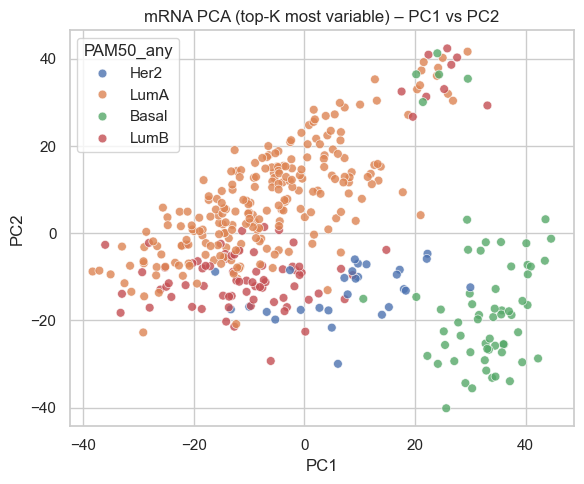

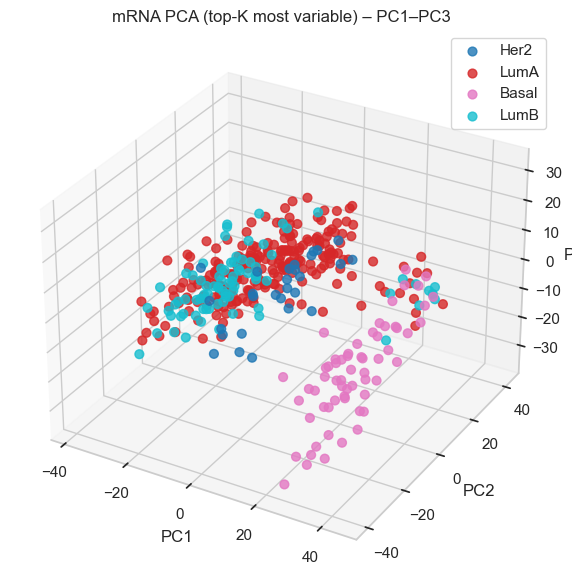

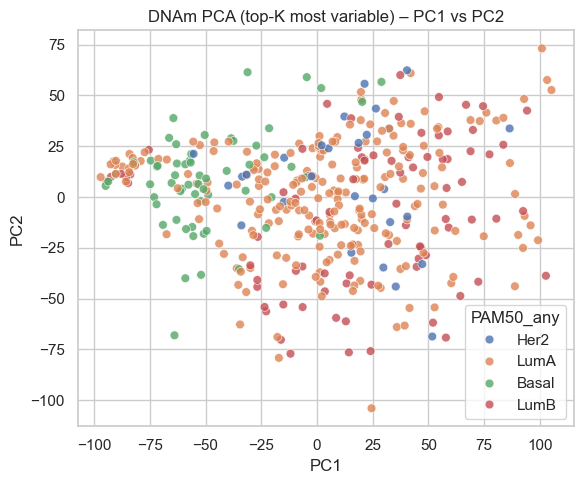

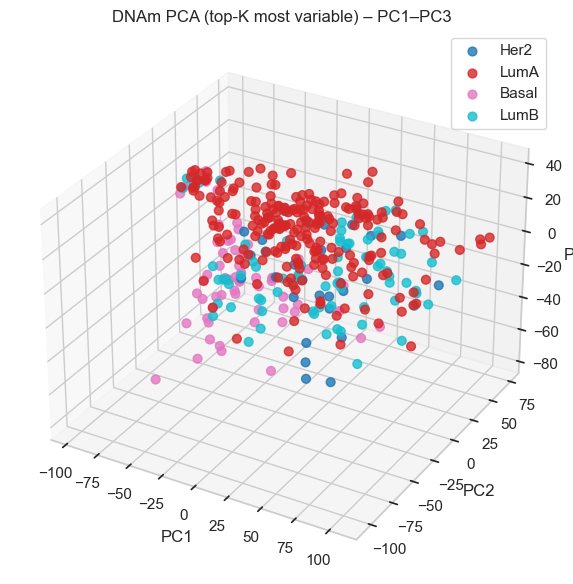

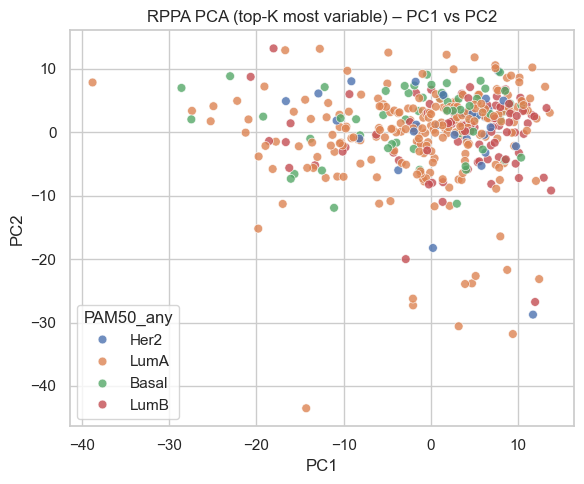

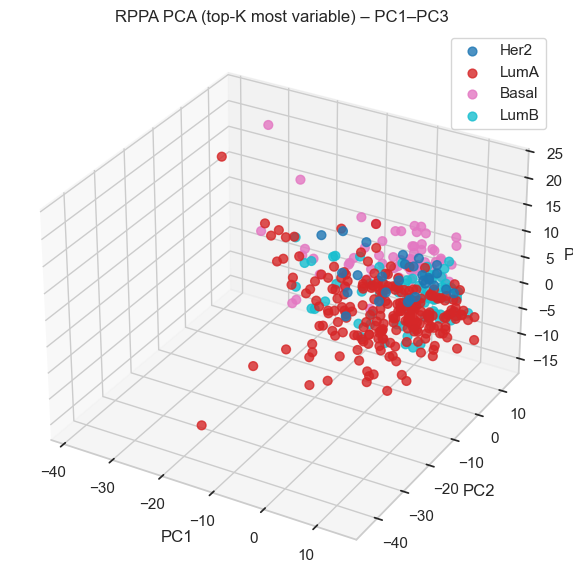

In [59]:
# === PCA per view: 2D and 3D (PC1–PC3) with PAM50_any labels ===

view_pca_scores = {
    "mRNA": scores_rna_15,
    "DNAm": scores_meth_15,
    "RPPA": scores_prot_15,
}

for view_name, scores_df in view_pca_scores.items():
    # 2D plot PC1 vs PC2
    plot_pca_2d(
        scores_df,
        labels=pam_pca,
        x_pc=1,
        y_pc=2,
        title=f"{view_name} PCA (top-K most variable) – PC1 vs PC2",
    )

    # 3D plot PC1, PC2, PC3
    plot_pca_3d(
        scores_df,
        labels=pam_pca,
        pcs=(1, 2, 3),
        title=f"{view_name} PCA (top-K most variable) – PC1–PC3",
    )


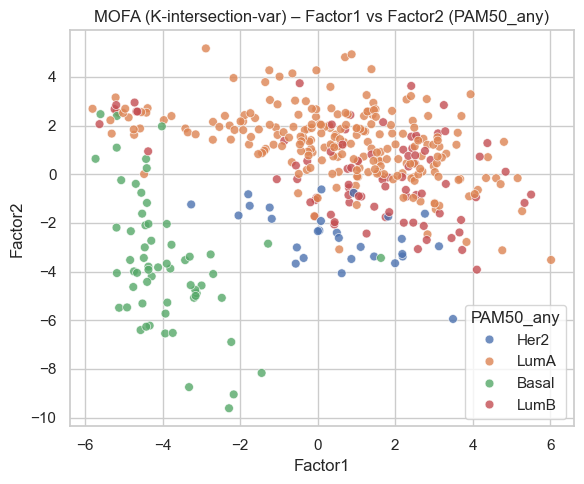

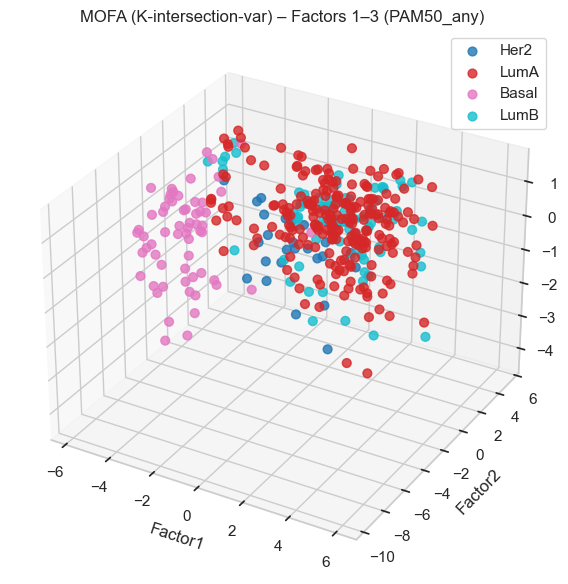

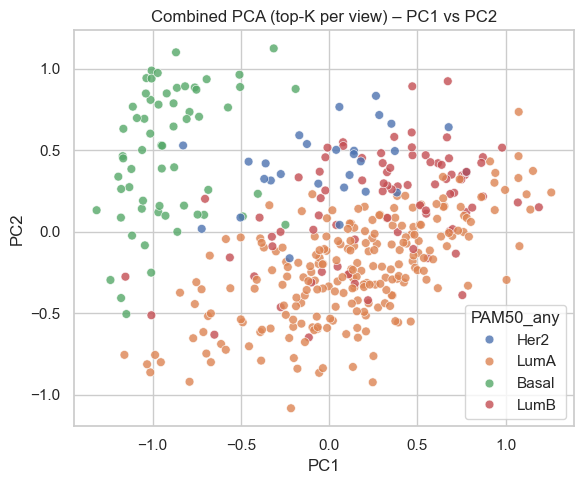

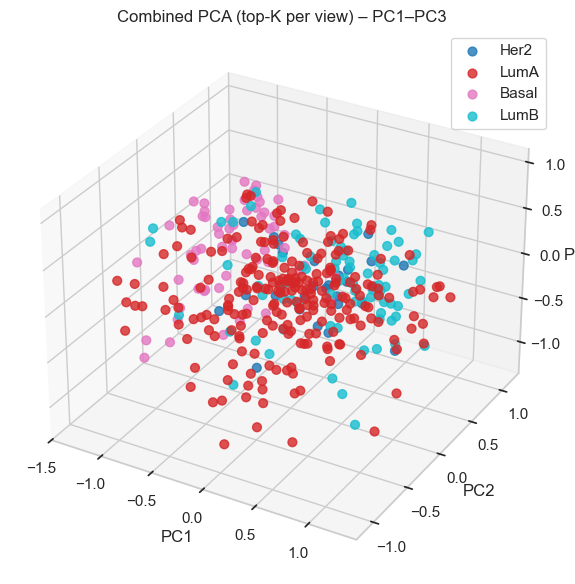

In [60]:
# MOFA – 2D and 3D
plot_mofa_2d(
    mofa_scores_15,
    labels=pam_pca,
    x_f=1,
    y_f=2,
    title="MOFA (K-intersection-var) – Factor1 vs Factor2 (PAM50_any)"
)

plot_mofa_3d(
    mofa_scores_15,
    labels=pam_pca,
    factors=(1, 2, 3),
    title="MOFA (K-intersection-var) – Factors 1–3 (PAM50_any)"
)

# Combined PCA – 2D and 3D
plot_pca_2d(
    scores_combined_15,
    labels=pam_pca,
    x_pc=1,
    y_pc=2,
    title="Combined PCA (top-K per view) – PC1 vs PC2"
)

plot_pca_3d(
    scores_combined_15,
    labels=pam_pca,
    pcs=(1, 2, 3),
    title="Combined PCA (top-K per view) – PC1–PC3"
)


### R² per factor and per view (MOFA vs combined PCA)

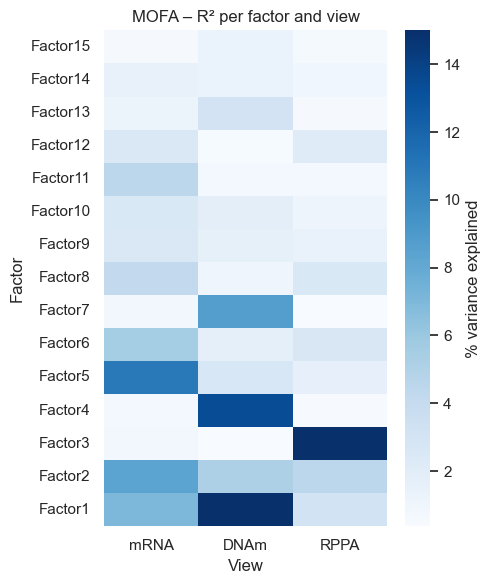

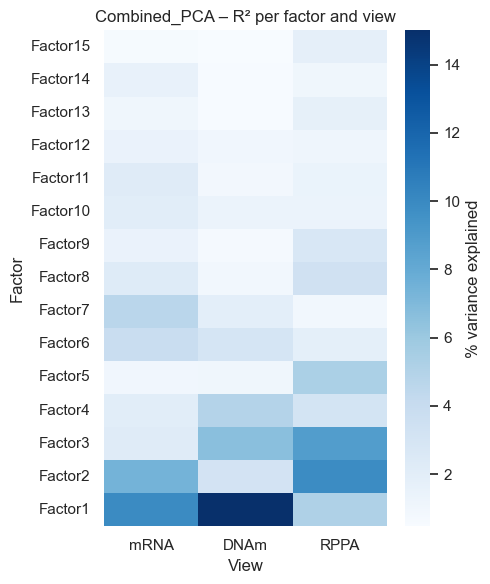

In [61]:
views_var = {
    "mRNA": filtered_data_var["mRNA"]["expr"].loc[patients_pca],
    "DNAm": filtered_data_var["DNAm"]["expr"].loc[patients_pca],
    "RPPA": filtered_data_var["RPPA"]["expr"].loc[patients_pca],
}

embeddings_r2 = {
    "MOFA":         mofa_scores_15,
    "Combined_PCA": scores_combined_15,
}

for emb_name, Z in embeddings_r2.items():
    r2_mat = per_factor_r2_matrix(views_var, Z, n_factors=N_FACTORS)
    r2_percent = 100 * r2_mat
    r2_percent_inv = r2_percent.iloc[::-1]  # Factor1 at bottom

    plt.figure(figsize=(5, 6))
    sns.heatmap(
        r2_percent_inv,
        cmap="Blues",
        vmax=15,
        cbar_kws={"label": "% variance explained"},
    )
    plt.title(f"{emb_name} – R² per factor and view")
    plt.xlabel("View")
    plt.ylabel("Factor")
    plt.tight_layout()
    plt.show()


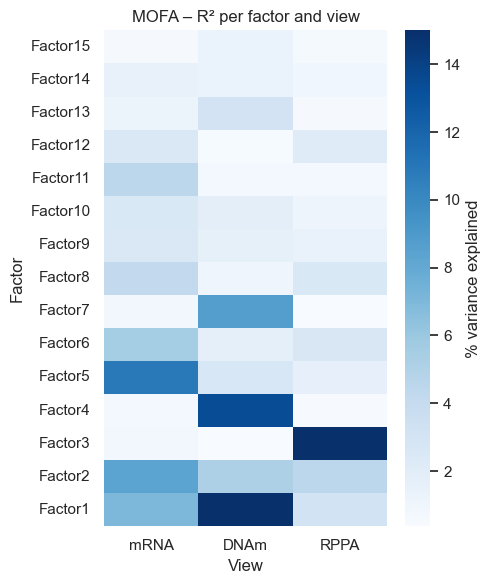

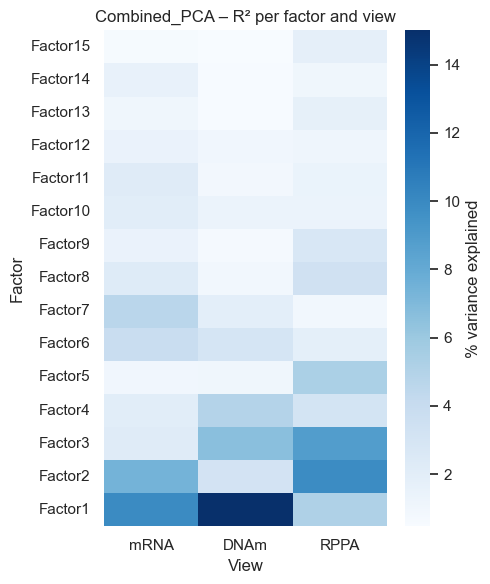

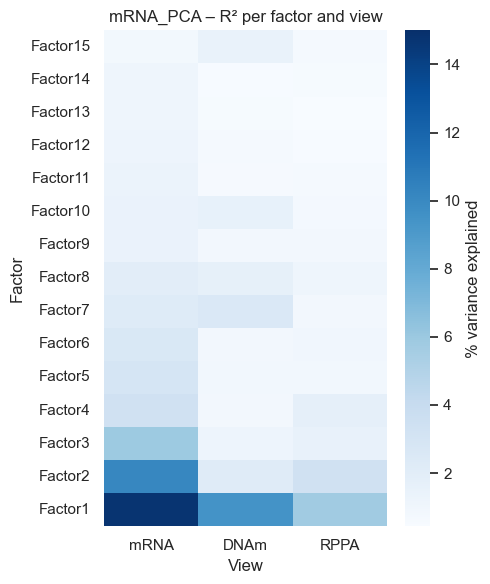

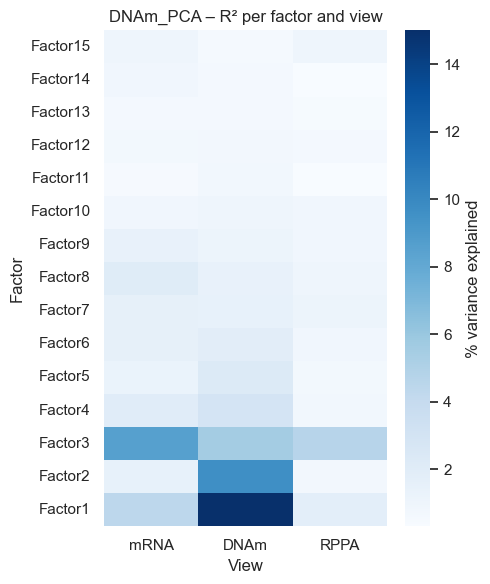

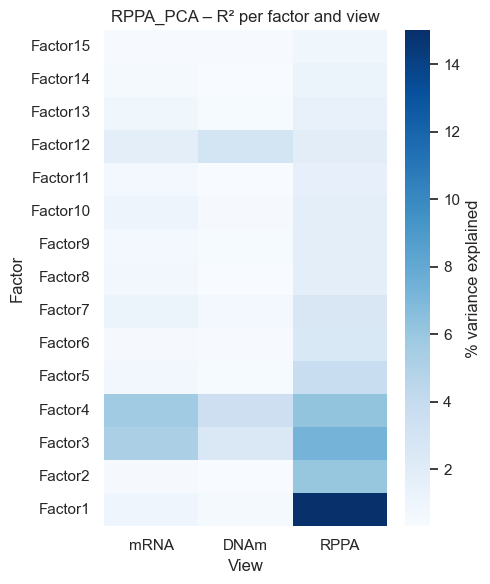

In [62]:
# === R² per factor and per view (MOFA + all PCAs) ===

views_var = {
    "mRNA": filtered_data_var["mRNA"]["expr"].loc[patients_pca],
    "DNAm": filtered_data_var["DNAm"]["expr"].loc[patients_pca],
    "RPPA": filtered_data_var["RPPA"]["expr"].loc[patients_pca],
}

embeddings_r2 = {
    "MOFA":         mofa_scores_15,
    "Combined_PCA": scores_combined_15,
    "mRNA_PCA":     scores_rna_15,
    "DNAm_PCA":     scores_meth_15,
    "RPPA_PCA":     scores_prot_15,
}

for emb_name, Z in embeddings_r2.items():
    r2_mat = per_factor_r2_matrix(views_var, Z, n_factors=N_FACTORS)
    r2_percent = 100 * r2_mat
    r2_percent_inv = r2_percent.iloc[::-1]  # Factor1 at bottom

    plt.figure(figsize=(5, 6))
    sns.heatmap(
        r2_percent_inv,
        cmap="Blues",
        vmax=15,
        cbar_kws={"label": "% variance explained"},
    )
    plt.title(f"{emb_name} – R² per factor and view")
    plt.xlabel("View")
    plt.ylabel("Factor")
    plt.tight_layout()
    plt.show()


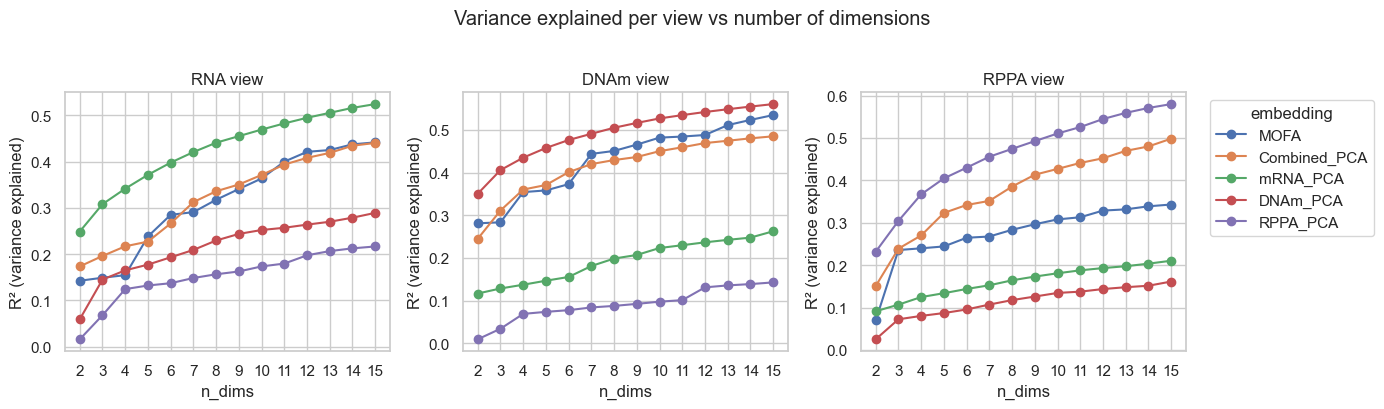

In [63]:
# === R² vs number of dimensions, per view & embedding ===

# 1) define views (already used for heatmaps)
# views_var = {
#     "mRNA": filtered_data_var["mRNA"]["expr"].loc[patients_pca],
#     "DNAm": filtered_data_var["DNAm"]["expr"].loc[patients_pca],
#     "RPPA": filtered_data_var["RPPA"]["expr"].loc[patients_pca],
# }

# 2) all embeddings we want to compare
embeddings_all = {
    "MOFA":         mofa_scores_15,
    "Combined_PCA": scores_combined_15,
    "mRNA_PCA":     scores_rna_15,
    "DNAm_PCA":     scores_meth_15,
    "RPPA_PCA":     scores_prot_15,
}

dims = range(2, N_PCS + 1)

# r2_curves[view] is a DataFrame (index = n_dims, columns = embeddings)
r2_curves = {
    vname: pd.DataFrame(index=dims, columns=embeddings_all.keys(), dtype=float)
    for vname in views_var.keys()
}

for vname, X_df in views_var.items():
    for d in dims:
        for emb_name, Z_df in embeddings_all.items():
            r2 = variance_explained_view(X_df, Z_df.iloc[:, :d])
            r2_curves[vname].loc[d, emb_name] = r2

# === Plot, 3 panels like your screenshot ===

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

view_order = ["mRNA", "DNAm", "RPPA"]
view_titles = {
    "mRNA": "RNA view",
    "DNAm": "DNAm view",
    "RPPA": "RPPA view",
}

for ax, vname in zip(axes, view_order):
    df = r2_curves[vname]
    for emb_name in df.columns:
        ax.plot(df.index, df[emb_name], marker="o", label=emb_name)
    ax.set_title(view_titles[vname])
    ax.set_xlabel("n_dims")
    ax.set_ylabel("R² (variance explained)")
    ax.set_xticks(list(dims))

# put legend only once (on the last axis or outside)
axes[-1].legend(title="embedding", bbox_to_anchor=(1.05, 1), loc="upper left")

fig.suptitle("Variance explained per view vs number of dimensions", y=1.02)
plt.tight_layout()
plt.show()


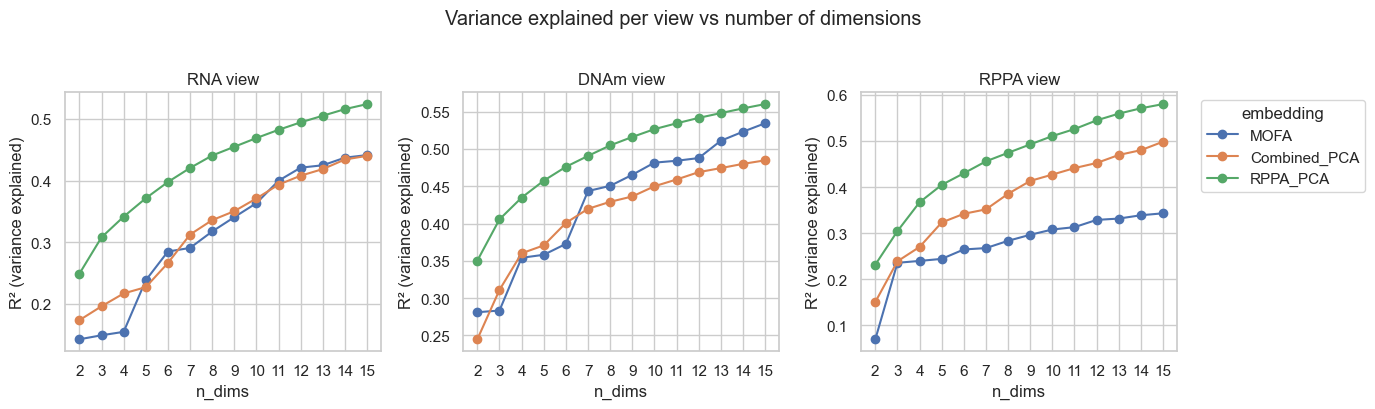

In [64]:
# === Plot, 3 panels, only: MOFA + Combined_PCA + view-specific PCA ===

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

view_order = ["mRNA", "DNAm", "RPPA"]
view_titles = {
    "mRNA": "RNA view",
    "DNAm": "DNAm view",
    "RPPA": "RPPA view",
}

# which curves to show for each view
view_to_cols = {
    "mRNA": ["MOFA", "Combined_PCA", "mRNA_PCA"],
    "DNAm": ["MOFA", "Combined_PCA", "DNAm_PCA"],
    "RPPA": ["MOFA", "Combined_PCA", "RPPA_PCA"],
}

for ax, vname in zip(axes, view_order):
    df = r2_curves[vname]
    cols = view_to_cols[vname]

    for emb_name in cols:
        ax.plot(df.index, df[emb_name], marker="o", label=emb_name)

    ax.set_title(view_titles[vname])
    ax.set_xlabel("n_dims")
    ax.set_ylabel("R² (variance explained)")
    ax.set_xticks(list(df.index))

# one legend for all panels
axes[-1].legend(title="embedding", bbox_to_anchor=(1.05, 1), loc="upper left")

fig.suptitle("Variance explained per view vs number of dimensions", y=1.02)
plt.tight_layout()
plt.show()


### Silhouette analysis (overall, dims 2–15)

In [65]:
dims = range(2, N_PCS + 1)

embeddings_sil = {
    "MOFA":         mofa_scores_15,
    "Combined_PCA": scores_combined_15,
}

overall_sil = pd.DataFrame(index=embeddings_sil.keys(), columns=dims, dtype=float)

for d in dims:
    for name, Z in embeddings_sil.items():
        overall_sil.loc[name, d] = silhouette_in_embedding(
            Z, pam_pca, n_dims=d
        )

overall_sil


,2,3,4,5,6,7,8,9,10,11,12,13,14,15
MOFA,0.102690,0.091628,0.088355,0.086932,0.063659,0.065266,0.070751,0.069866,0.097651,0.092755,0.089368,0.087605,0.086931,0.086260
Combined_PCA,0.125079,0.094697,0.084401,0.071938,0.069453,0.067285,0.071623,0.077829,0.075882,0.074027,0.074440,0.073727,0.072786,0.074337


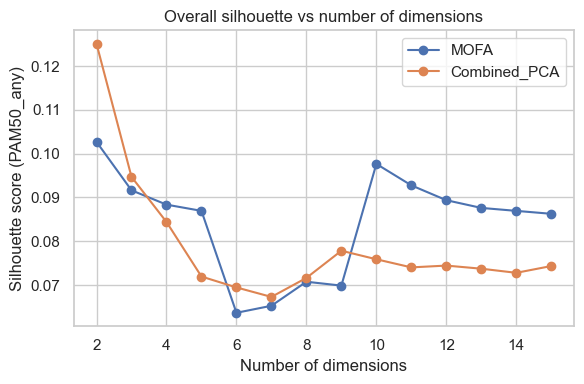

In [66]:
plt.figure(figsize=(6, 4))
for name in embeddings_sil.keys():
    plt.plot(dims, overall_sil.loc[name], marker="o", label=name)

plt.xlabel("Number of dimensions")
plt.ylabel("Silhouette score (PAM50_any)")
plt.title("Overall silhouette vs number of dimensions")
plt.legend()
plt.tight_layout()
plt.show()


### Factor ↔ subtype correlation matrix (MOFA)

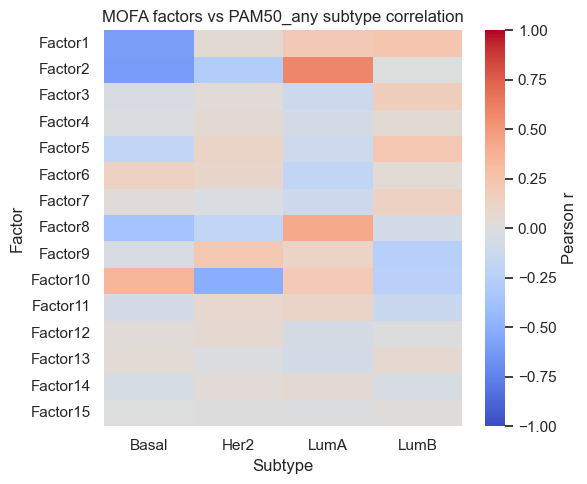

In [67]:
corr_mofa = factor_class_correlation_matrix(
    mofa_scores_15,
    pam_pca,
    n_factors=N_FACTORS,
)
corr_mofa

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_mofa,
    cmap="coolwarm",
    center=0.0,
    vmin=-1.0,
    vmax=1.0,
    cbar_kws={"label": "Pearson r"},
)
plt.title("MOFA factors vs PAM50_any subtype correlation")
plt.xlabel("Subtype")
plt.ylabel("Factor")
plt.tight_layout()
plt.show()


### Logistic regression CV (MOFA vs combined PCA, with std)

MOFA (K-intersection-var): best params {'clf__C': 0.01, 'clf__penalty': 'l2'}
CV balanced accuracy: 0.816 ± 0.046
Test balanced accuracy: 0.679
Test accuracy:        0.716
Test ROC-AUC (OvR):   0.887

Classification report:
              precision    recall  f1-score   support

       Basal       0.91      0.83      0.87        12
        Her2       0.40      0.67      0.50         6
        LumA       0.82      0.80      0.81        46
        LumB       0.47      0.41      0.44        17

    accuracy                           0.72        81
   macro avg       0.65      0.68      0.66        81
weighted avg       0.73      0.72      0.72        81



C:\Users\Petar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


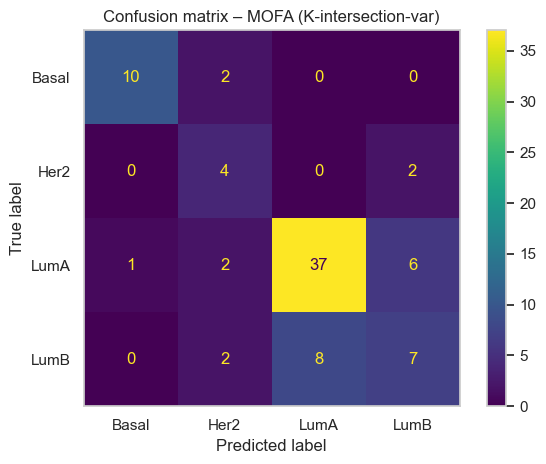

Combined PCA (top-K per view): best params {'clf__C': 1.0, 'clf__penalty': 'l1'}
CV balanced accuracy: 0.838 ± 0.085
Test balanced accuracy: 0.766
Test accuracy:        0.802
Test ROC-AUC (OvR):   0.904

Classification report:
              precision    recall  f1-score   support

       Basal       0.92      1.00      0.96        12
        Her2       0.80      0.67      0.73         6
        LumA       0.85      0.87      0.86        46
        LumB       0.56      0.53      0.55        17

    accuracy                           0.80        81
   macro avg       0.78      0.77      0.77        81
weighted avg       0.80      0.80      0.80        81



C:\Users\Petar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


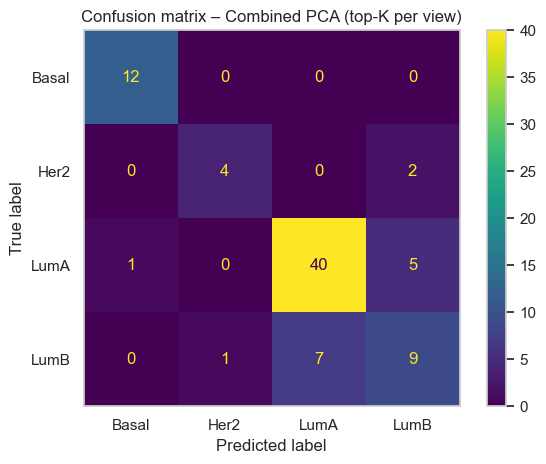

,best_params,mean_cv_bal_acc,std_cv_bal_acc,test_bal_acc,test_acc,test_roc_auc_ovr
title,,,,,,
MOFA (K-intersection-var),"{'clf__C': 0.01, 'clf__penalty': 'l2'}",0.815951,0.045642,0.679028,0.716049,0.886647
Combined PCA (top-K per view),"{'clf__C': 1.0, 'clf__penalty': 'l1'}",0.838230,0.084879,0.766411,0.802469,0.903726


In [68]:
results_mofa = run_logreg_on_factors(
    X_factors=mofa_scores_15,
    labels_any=pam_pca,
    title="MOFA (K-intersection-var)",
    verbose=True,
)

results_pca = run_logreg_on_factors(
    X_factors=scores_combined_15,
    labels_any=pam_pca,
    title="Combined PCA (top-K per view)",
    verbose=True,
)

pd.DataFrame([results_mofa, results_pca]).set_index("title")


RNA (K-intersection-var): best params {'clf__C': 1.0, 'clf__penalty': 'l1'}
CV balanced accuracy: 0.845 ± 0.062
Test balanced accuracy: 0.817
Test accuracy:        0.815
Test ROC-AUC (OvR):   0.918

Classification report:
              precision    recall  f1-score   support

       Basal       0.86      1.00      0.92        12
        Her2       0.83      0.83      0.83         6
        LumA       0.87      0.85      0.86        46
        LumB       0.62      0.59      0.61        17

    accuracy                           0.81        81
   macro avg       0.80      0.82      0.80        81
weighted avg       0.81      0.81      0.81        81



C:\Users\Petar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


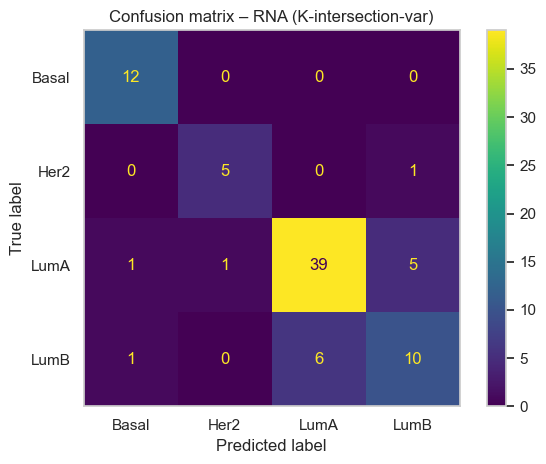

DNA (K-intersection-var): best params {'clf__C': 0.1, 'clf__penalty': 'l1'}
CV balanced accuracy: 0.762 ± 0.024
Test balanced accuracy: 0.685
Test accuracy:        0.716
Test ROC-AUC (OvR):   0.878

Classification report:
              precision    recall  f1-score   support

       Basal       0.85      0.92      0.88        12
        Her2       0.40      0.67      0.50         6
        LumA       0.80      0.80      0.80        46
        LumB       0.50      0.35      0.41        17

    accuracy                           0.72        81
   macro avg       0.64      0.69      0.65        81
weighted avg       0.72      0.72      0.71        81



C:\Users\Petar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


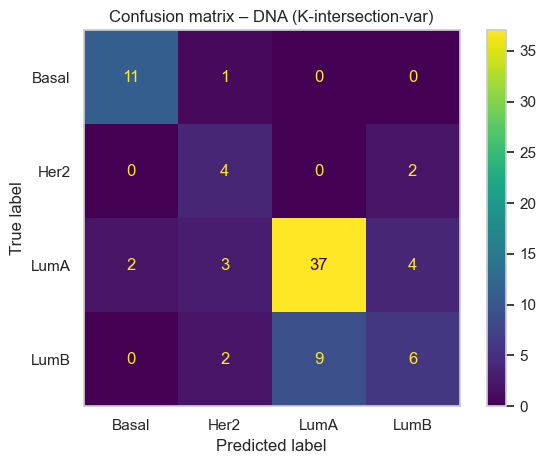

RPPA (K-intersection-var): best params {'clf__C': 0.1, 'clf__penalty': 'l2'}
CV balanced accuracy: 0.795 ± 0.046
Test balanced accuracy: 0.766
Test accuracy:        0.802
Test ROC-AUC (OvR):   0.924

Classification report:
              precision    recall  f1-score   support

       Basal       0.90      0.75      0.82        12
        Her2       0.62      0.83      0.71         6
        LumA       0.85      0.89      0.87        46
        LumB       0.67      0.59      0.62        17

    accuracy                           0.80        81
   macro avg       0.76      0.77      0.76        81
weighted avg       0.80      0.80      0.80        81



C:\Users\Petar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


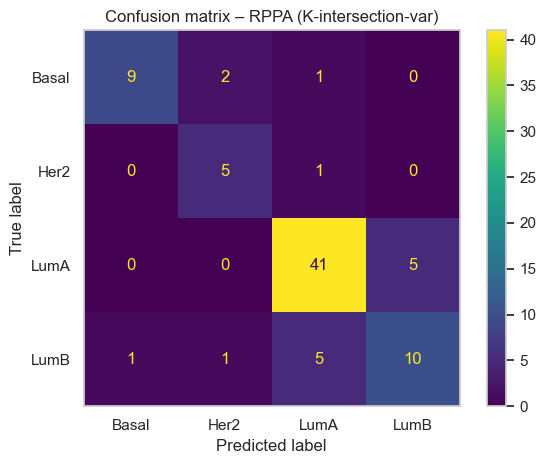

,best_params,mean_cv_bal_acc,std_cv_bal_acc,test_bal_acc,test_acc,test_roc_auc_ovr
title,,,,,,
MOFA (K-intersection-var),"{'clf__C': 0.01, 'clf__penalty': 'l2'}",0.815951,0.045642,0.679028,0.716049,0.886647
Combined PCA (top-K per view),"{'clf__C': 1.0, 'clf__penalty': 'l1'}",0.838230,0.084879,0.766411,0.802469,0.903726
RNA (K-intersection-var),"{'clf__C': 1.0, 'clf__penalty': 'l1'}",0.844758,0.062450,0.817349,0.814815,0.918015
DNA (K-intersection-var),"{'clf__C': 0.1, 'clf__penalty': 'l1'}",0.761704,0.024155,0.685156,0.716049,0.878451
RPPA (K-intersection-var),"{'clf__C': 0.1, 'clf__penalty': 'l2'}",0.794829,0.046372,0.765718,0.802469,0.924120


In [70]:
results_pca_rna = run_logreg_on_factors(
    X_factors=scores_rna_15,
    labels_any=pam_pca,
    title="RNA (K-intersection-var)",
    verbose=True,
)

results_pca_dna = run_logreg_on_factors(
    X_factors=scores_meth_15,
    labels_any=pam_pca,
    title="DNA (K-intersection-var)",
    verbose=True,
)

results_pca_rppa = run_logreg_on_factors(
    X_factors=scores_prot_15,
    labels_any=pam_pca,
    title="RPPA (K-intersection-var)",
    verbose=True,
)

pd.DataFrame([results_mofa, results_pca, results_pca_rna, results_pca_dna,results_pca_rppa]).set_index("title")
